# MCDI500 — Programación para la Ciencia de Datos
## Proyecto Transversal — Fase 3: Núcleo Algorítmico y Programación Orientada a Objetos

**Título del proyecto:** Factores socioeconómicos y de preparación previa asociados al rendimiento académico

| Campo | Detalle |
|---|---|
| **Curso** | MCDI500 — Programación para la Ciencia de Datos |
| **Docente** | Omar Salinas Silva |
| **Grupo** | Grupo 7 |
| **Integrantes** | Juan de Dios Díaz Ríos · Francisco Fariña Molina · Constanza Moreno Giacometto · Yenne Sepúlveda Jerez |
| **Fecha** | Junio 2026 |
| **Dataset** | Student Performance Dataset (Cortez & Silva, 2008) — UCI Machine Learning Repository |

---

## Índice

1. [Contexto: de la Fase 2 a la Fase 3](#1)
2. [Diseño de la clase `PreprocesadorAsignatura`](#2)
3. [Uso de la clase con datos reales](#3)
4. [Herencia y polimorfismo: `PreprocesadorMatematicas` y `PreprocesadorPortugues`](#4)
5. [Recursividad](#5)
   - 5.1 Esqueleto general de un algoritmo recursivo
   - 5.2 Merge Sort aplicado a las notas del dataset
6. [Eficiencia —  Comparativa de tiempos de ejecución](#6)
7. [Validación y exportación final mediante objetos](#7)
8. [Bibliografia (APA 7) ](#8)


---
<a id='1'></a>
## 1. Contexto: de la Fase 2 a la Fase 3

En la **Fase 2** el equipo desarrolló un pipeline de **obtención, limpieza y transformación de datos**
implementado mediante **funciones** encapsuladas en `src/functions.py`: `cargar_dataset()`,
`resumen_dataset()`, `validar_rangos()`, `detectar_outliers_iqr()`, `analizar_correlaciones()`,
`limpiar_dataset()`, `winsorizacion()`, `codificar_binarias()`, `codificar_ohe()`,
`crear_variables_derivadas()`, `validar_dataset_final()` y `exportar_dataset()`.

Ese pipeline funciona correctamente, pero los datos (`df_mat`, `df_por`, `df_mat_enc`, `df_por_enc`,
etc.) y los pasos del proceso quedan **sueltos** en el notebook: cada función recibe un `DataFrame`,
lo transforma y lo retorna, y es responsabilidad de quien lee el notebook recordar en qué estado
quedó cada variable.

La **Fase 3** consolida ese pipeline dentro de un **núcleo algorítmico orientado a objetos**. La idea
central es la misma que vimos con la clase `Preprocesador` en la guía de la Semana 2:
juntar en un mismo lugar — un **objeto** — **los datos** (`self.df`, `self.df_enc`) y **las acciones**
que operan sobre ellos (`cargar()`, `explorar()`, `limpiar()`, `transformar()`, `validar()`,
`exportar()`).

**Lo importante:** esta capa de POO **no reemplaza** las funciones de la Fase 2 — las **reutiliza**.
Cada método de la nueva clase `PreprocesadorAsignatura` (definida en `src/clases.py`) llama
internamente a las funciones ya validadas de `functions.py`. Esto cumple con el objetivo de la
Fase 3: *"integrar estos resultados previos con la implementación inicial del núcleo algorítmico del
sistema, incorporando principios de POO"*.

Adicionalmente, en este notebook se incorporan:
- **Herencia y polimorfismo** (Sección 4): `PreprocesadorMatematicas` y `PreprocesadorPortugues`
  heredan de `PreprocesadorAsignatura` y cada una implementa su propia interpretación de los
  resultados de correlación obtenidos en la Fase 2.
- **Recursividad** (Sección 5): un ejemplo aplicado al proyecto — ordenando los notas de g3 mediante logica recursiva, separandolo la data en 2
- **Eficiencia y complejidad** (Sección 6): comparación de tiempos de ejecución entre
  implementaciones con bucles y sus equivalentes vectorizados con NumPy/Pandas, en relación a la aprobación (g3>=10)

In [1]:
# ============================================================
# ENTORNO E IMPORTACIÓN DE MÓDULOS DEL PROYECTO
# ============================================================
import sys, os
sys.path.append(os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import timeit

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

# Funciones de la Fase 2 (pipeline funcional ya validado)
from functions import (
    cargar_dataset, mostrar_primeras_filas, resumen_dataset,
    validar_rangos, detectar_outliers_iqr, analizar_correlaciones,
    analizar_g3_cero, limpiar_dataset, winsorizacion,
    codificar_binarias, codificar_ohe, crear_variables_derivadas,
    validar_dataset_final, exportar_dataset, integrar_datasets, merge_sort, 
    combinar,aprobado_bucle, aprobado_vectorizado
)

# Núcleo algorítmico de la Fase 3: clases (POO) y funciones recursivas
from clases import PreprocesadorAsignatura, PreprocesadorMatematicas, PreprocesadorPortugues


print("✓ Entorno listo. Módulos de Fase 2 (functions) y Fase 3 (clases) importados.")

✓ Entorno listo. Módulos de Fase 2 (functions) y Fase 3 (clases) importados.


---
<a id='2'></a>
## 2. Diseño de la clase `PreprocesadorAsignatura`

### 2.1 Los 5 conceptos de POO aplicados a nuestro proyecto

| Concepto | Qué es | En nuestro proyecto |
|---|---|---|
| **Clase** | El molde o plantilla. | `class PreprocesadorAsignatura:` |
| **Objeto** | Una instancia creada a partir de la clase. | `prep_mat = PreprocesadorMatematicas()` |
| **Atributo** | Un dato que vive dentro del objeto. | `self.df`, `self.df_enc`, `self.asignatura` |
| **Método** | Una acción del objeto. | `prep_mat.limpiar()`, `prep_mat.transformar()` |
| **`self`** | El objeto se refiere a sí mismo. | `self.df = winsorizacion(self.df, ...)` |

El **constructor** (`__init__`) deja listos los atributos del objeto apenas se crea: la ruta del CSV,
la asignatura (`'mat'` o `'por'`) y tres "casilleros" vacíos (`df_raw`, `df`, `df_enc`) que se irán
llenando a medida que se ejecutan los métodos del pipeline.

### 2.2 Métodos de la clase

La clase `PreprocesadorAsignatura` (definida en `src/clases.py`) encapsula **todo el pipeline de la
Fase 2** en seis métodos, cada uno reutilizando las funciones ya construidas:

| Método | Qué hace | Funciones de Fase 2 que reutiliza |
|---|---|---|
| `cargar()` | Lee el CSV crudo y crea `self.df_raw` / `self.df` | `cargar_dataset()` |
| `explorar()` | Diagnóstico: resumen, rangos, outliers, G3=0 | `resumen_dataset()`, `estadisticas_descriptivas()`,`plot_distribucion_categoricas()`,`validar_rangos()`, `detectar_outliers_iqr()`, `analizar_g3_cero()` |
| `limpiar()` | Flags + winsorización de `absences` | `limpiar_dataset()`, `winsorizacion()` |
| `transformar()` | Codificación binaria + OHE + variables derivadas | `codificar_binarias()`, `codificar_ohe()`, `crear_variables_derivadas()` |
| `validar()` | Asserts de integridad post-procesamiento | `validar_dataset_final()` |
| `exportar()` | Exporta `self.df` y `self.df_enc` a `data/processed/` | `exportar_dataset()` |

Además, `ejecutar_pipeline()` es un **método de alto nivel** que orquesta los seis anteriores en el
orden correcto — exactamente la misma secuencia que se siguió "a mano" en el notebook de la Fase 2.

A continuación se muestra el código completo de la clase base (también disponible en
`src/clases.py`).

In [2]:
# ============================================================
# Código fuente de la clase base (src/clases.py)
# Se muestra aquí con fines didácticos; el notebook importa
# la clase ya definida en el módulo.
# ============================================================
import inspect
from clases import PreprocesadorAsignatura
print(inspect.getsource(PreprocesadorAsignatura))

class PreprocesadorAsignatura:
    """Clase base que encapsula el pipeline completo de la Fase 2
    (carga -> exploración -> limpieza -> transformación -> validación
    -> exportación) para UNA asignatura del Student Performance Dataset.

    Atributos de instancia
    -----------------------
    ruta : str
        Ruta al CSV crudo (data/raw/...).
    asignatura : str
        Identificador corto de la asignatura ('mat' o 'por').
    df_raw : pd.DataFrame | None
        Copia inmutable de los datos originales (tal cual se cargan).
    df : pd.DataFrame | None
        Copia de trabajo: se actualiza en limpiar().
    df_enc : pd.DataFrame | None
        Versión codificada/transformada (resultado de transformar()).

    Atributo de clase
    -----------------
    NOMBRE_ASIGNATURA : str
        Nombre legible de la asignatura. Se sobrescribe en cada
        clase hija (PreprocesadorMatematicas, PreprocesadorPortugues).
    """

    NOMBRE_ASIGNATURA = "Genérica"

    def __init__(self, 

---
<a id='3'></a>
## 3. Uso de la clase con datos reales

Creamos **dos objetos**, uno por asignatura, y ejecutamos el pipeline completo de cada uno con
`ejecutar_pipeline()`. Observa que ya no necesitamos ir pasando `df_mat`, `df_mat_clean`,
`df_mat_enc`, etc. de función en función: toda esa información vive **dentro de cada objeto**
(`prep_mat.df`, `prep_mat.df_enc`, ...).

> Por ahora usamos `PreprocesadorMatematicas` y `PreprocesadorPortugues` (clases hijas, ver Sección
> 4). Para esta sección basta con saber que ambas heredan el pipeline completo de
> `PreprocesadorAsignatura`.

In [3]:
# 1) Creamos los objetos (esto ejecuta __init__ de cada clase)
prep_mat = PreprocesadorMatematicas("../data/raw/student-mat.csv")
prep_por = PreprocesadorPortugues("../data/raw/student-por.csv")

print(repr(prep_mat))
print(repr(prep_por))

<PreprocesadorMatematicas asignatura='mat' | df=sin cargar | df_enc=sin transformar>
<PreprocesadorPortugues asignatura='por' | df=sin cargar | df_enc=sin transformar>



  PIPELINE — Matemáticas  (objeto: PreprocesadorMatematicas)
  ✓ Matemáticas: 395 filas × 33 columnas cargadas desde '../data/raw/student-mat.csv'

Primeras filas:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4     

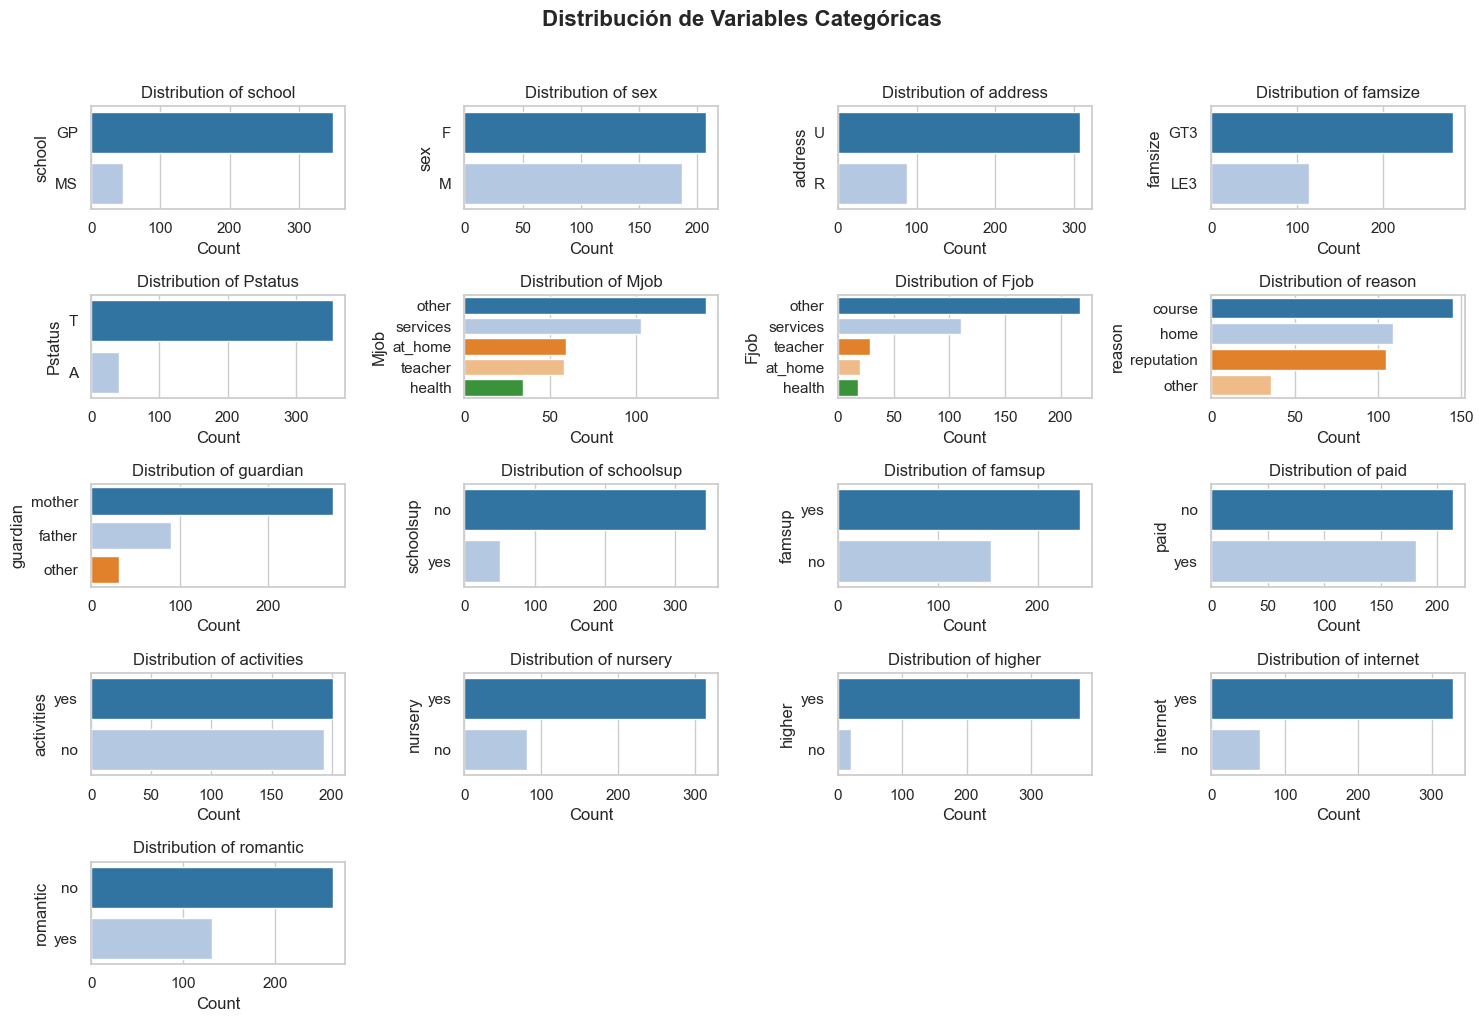


  DETECCIÓN OUTLIERS (IQR) — Matemáticas
  ⚠ age        Q1=16.0 Q3=18.0 IQR=2.0 límites=[13.0,21.0] outliers=1 (0.3%)
  ⚠ absences   Q1=0.0 Q3=8.0 IQR=8.0 límites=[-12.0,20.0] outliers=15 (3.8%)
  ✓ G1         Q1=8.0 Q3=13.0 IQR=5.0 límites=[0.5,20.5] outliers=0 (0.0%)
  ⚠ G2         Q1=9.0 Q3=13.0 IQR=4.0 límites=[3.0,19.0] outliers=13 (3.3%)
  ✓ G3         Q1=8.0 Q3=14.0 IQR=6.0 límites=[-1.0,23.0] outliers=0 (0.0%)


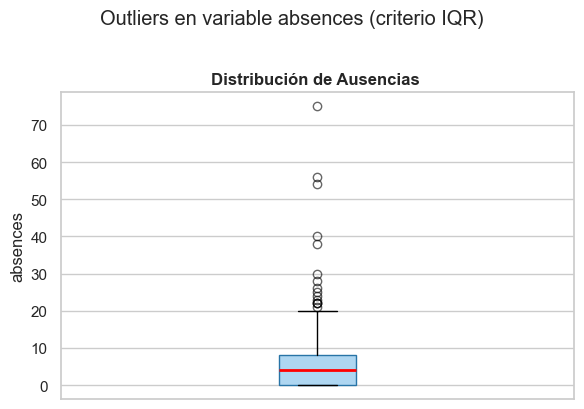


ANÁLISIS DE CORRELACIONES — Matemáticas

Variables numéricas consideradas: 16

Correlaciones con nota final G3:
G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


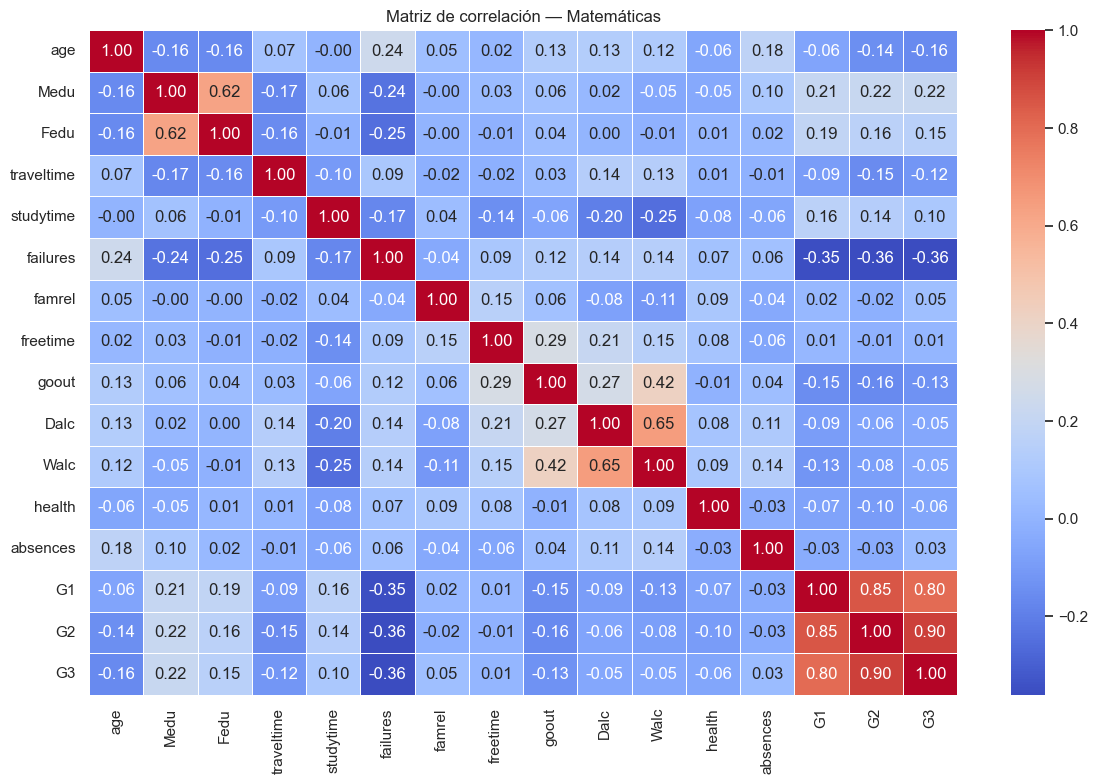


=== Análisis G3 = 0 ===
  Matemáticas: G3=0 total=38 | G2=0 y G3=0 (deserción)=13 | G2>0 y G3=0 (reprobado)=25


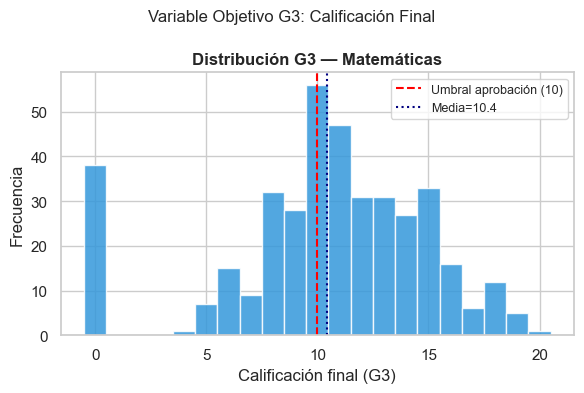


  Pipeline de limpieza — MAT
  [1] Duplicados eliminados : 0  (ninguno)
  [2] Strip en 17 columnas de texto ✓
  [3] Flag 'desercion' creado: 13 casos
  [4] Columna 'asignatura' = 'mat' ✓
  Resultado: 395 → 395 filas
  Winsorización 'absences': cap p95=18 → 20 valores ajustados
  Codificación binaria: 8 vars yes/no + 5 vars propias
  OHE aplicado en ['Mjob', 'Fjob', 'reason', 'guardian'] → 9 nuevas columnas
  Variables derivadas creadas: ['aprobado', 'progreso_g1_g3', 'nivel_alcohol', 'edu_familiar_media']

  Validando: Matemáticas
  ✓ Filas conservadas: 395
  ✓ Sin nulos en columnas originales
  ✓ G1, G2, G3 intactos
  ✓ Flag 'aprobado' coherente (265 aprobados)
  ✓ Flag 'desercion' coherente (13 casos)
  ✓ Sin filas duplicadas
  ✓ G1, G2, G3 en rango [0, 20]
  → VALIDACIÓN EXITOSA ✅
  ✓ student_mat_clean.csv                       395f ×  36c  (45.6 KB)
    → Matemáticas limpio: flags + winsorización (sin OHE)
  ✓ student_mat_clean_encode.csv                395f ×  54c  (48.5 KB)
    

In [4]:
# 2) Ejecutamos el pipeline completo para Matemáticas
ok_mat = prep_mat.ejecutar_pipeline(exportar_resultados=True)


  PIPELINE — Portugués  (objeto: PreprocesadorPortugues)
  ✓ Portugués: 649 filas × 33 columnas cargadas desde '../data/raw/student-por.csv'

Primeras filas:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3  

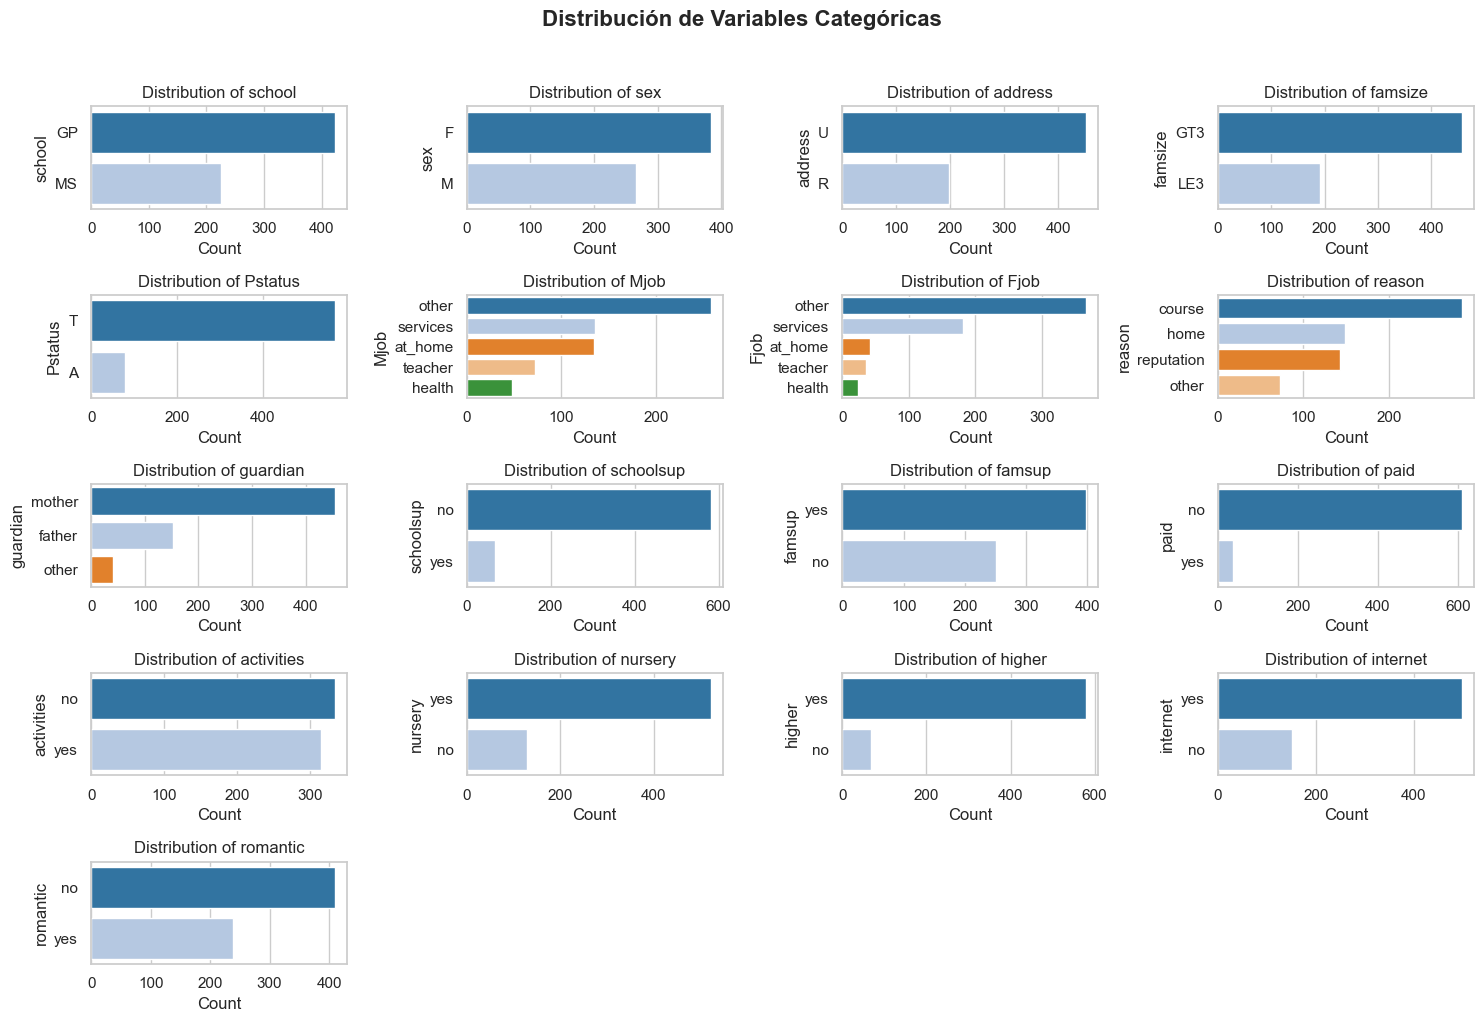


  DETECCIÓN OUTLIERS (IQR) — Portugués
  ⚠ age        Q1=16.0 Q3=18.0 IQR=2.0 límites=[13.0,21.0] outliers=1 (0.2%)
  ⚠ absences   Q1=0.0 Q3=6.0 IQR=6.0 límites=[-9.0,15.0] outliers=21 (3.2%)
  ⚠ G1         Q1=10.0 Q3=13.0 IQR=3.0 límites=[5.5,17.5] outliers=16 (2.5%)
  ⚠ G2         Q1=10.0 Q3=13.0 IQR=3.0 límites=[5.5,17.5] outliers=25 (3.9%)
  ⚠ G3         Q1=10.0 Q3=14.0 IQR=4.0 límites=[4.0,20.0] outliers=16 (2.5%)


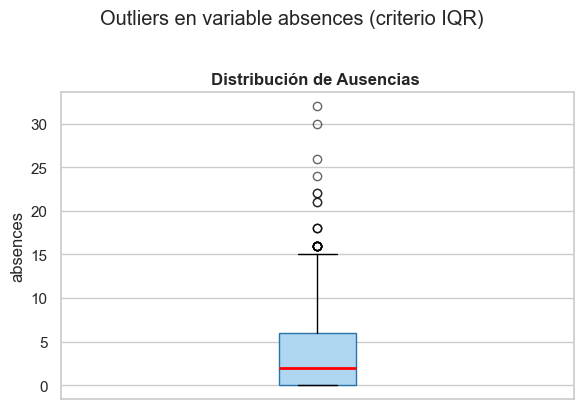


ANÁLISIS DE CORRELACIONES — Portugués

Variables numéricas consideradas: 16

Correlaciones con nota final G3:
G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64


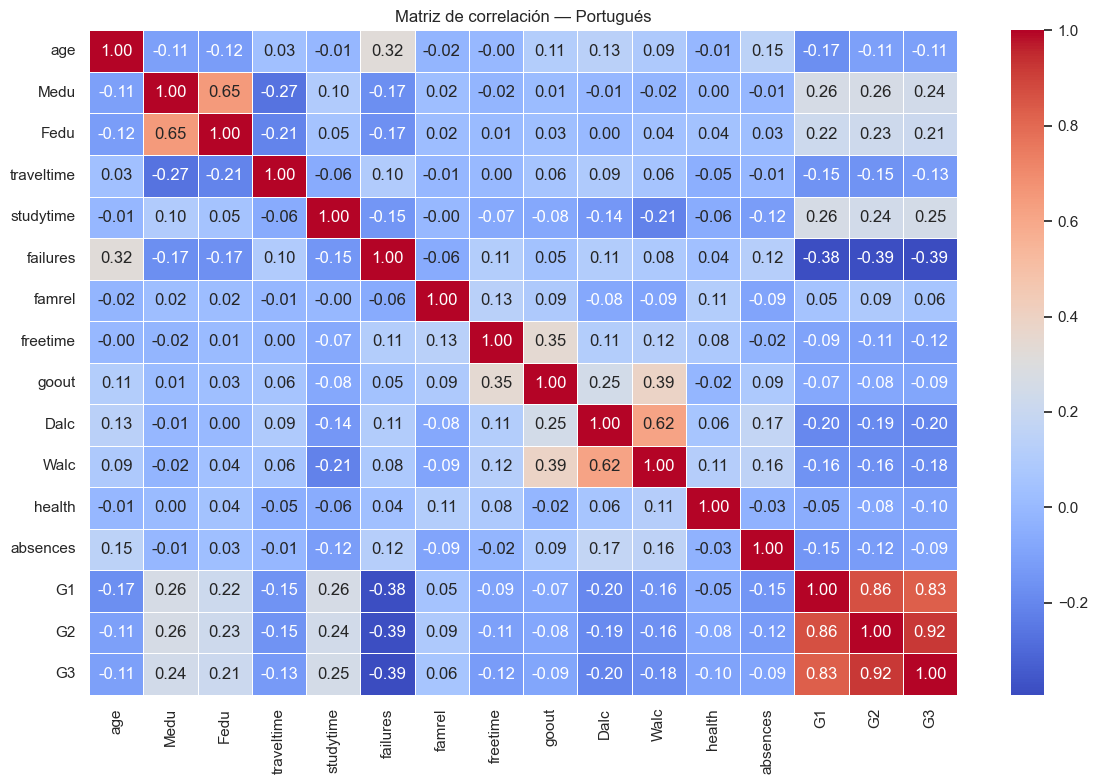


=== Análisis G3 = 0 ===
  Portugués: G3=0 total=15 | G2=0 y G3=0 (deserción)=7 | G2>0 y G3=0 (reprobado)=8


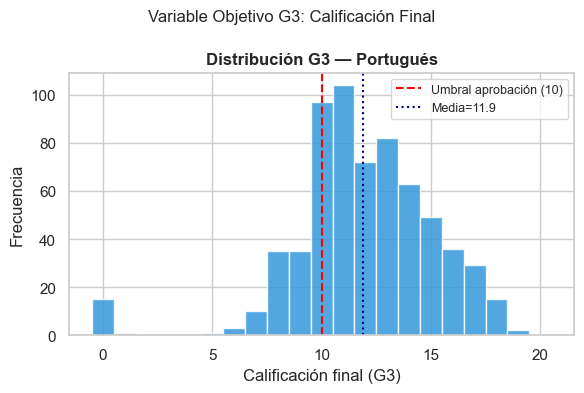


  Pipeline de limpieza — POR
  [1] Duplicados eliminados : 0  (ninguno)
  [2] Strip en 17 columnas de texto ✓
  [3] Flag 'desercion' creado: 7 casos
  [4] Columna 'asignatura' = 'por' ✓
  Resultado: 649 → 649 filas
  Winsorización 'absences': cap p95=12 → 32 valores ajustados
  Codificación binaria: 8 vars yes/no + 5 vars propias
  OHE aplicado en ['Mjob', 'Fjob', 'reason', 'guardian'] → 9 nuevas columnas
  Variables derivadas creadas: ['aprobado', 'progreso_g1_g3', 'nivel_alcohol', 'edu_familiar_media']

  Validando: Portugués
  ✓ Filas conservadas: 649
  ✓ Sin nulos en columnas originales
  ✓ G1, G2, G3 intactos
  ✓ Flag 'aprobado' coherente (549 aprobados)
  ✓ Flag 'desercion' coherente (7 casos)
  ✓ Sin filas duplicadas
  ✓ G1, G2, G3 en rango [0, 20]
  → VALIDACIÓN EXITOSA ✅
  ✓ student_por_clean.csv                       649f ×  36c  (72.8 KB)
    → Portugués limpio: flags + winsorización (sin OHE)
  ✓ student_por_clean_encode.csv                649f ×  54c  (77.7 KB)
    → Port

In [5]:
# 3) Ejecutamos el pipeline completo para Portugués
ok_por = prep_por.ejecutar_pipeline(exportar_resultados=True)

**Resultado:** ambos objetos ejecutaron el pipeline completo de la Fase 2 (carga, exploración,
limpieza, transformación, validación y exportación) con una sola llamada a `ejecutar_pipeline()`.
Los resultados — número de filas, flags de deserción, valores de winsorización, dimensiones finales
— son **idénticos** a los obtenidos "a mano" en el notebook de la Fase 2, porque internamente se
están usando **las mismas funciones**.

In [6]:
# La tabla final de cada asignatura vive dentro del objeto correspondiente
print("Vista previa — Matemáticas (prep_mat.df_enc):")
mostrar_primeras_filas(prep_mat.df_enc, 5)

Vista previa — Matemáticas (prep_mat.df_enc):


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,aprobado,progreso_g1_g3,nivel_alcohol,edu_familiar_media
0,GP,F,18,U,GT3,A,4,4,2,2,...,1,0,0,0,1,0,0,1,1.0,4.0
1,GP,F,17,U,GT3,T,1,1,1,2,...,0,0,0,0,0,0,0,1,1.0,1.0
2,GP,F,15,U,LE3,T,1,1,1,2,...,0,0,1,0,1,0,1,3,2.5,1.0
3,GP,F,15,U,GT3,T,4,2,1,3,...,0,1,0,0,1,0,1,0,1.0,3.0
4,GP,F,16,U,GT3,T,3,3,1,2,...,0,1,0,0,0,0,1,4,1.5,3.0


In [7]:
print(repr(prep_mat))
print(repr(prep_por))

<PreprocesadorMatematicas asignatura='mat' | df=395 filas × 36 cols | df_enc=395 filas × 54 cols>
<PreprocesadorPortugues asignatura='por' | df=649 filas × 36 cols | df_enc=649 filas × 54 cols>


---
<a id='4'></a>
## 4. Herencia y polimorfismo: `PreprocesadorMatematicas` y `PreprocesadorPortugues`

### 4.1 ¿Por qué herencia aquí?

Las dos asignaturas comparten **exactamente el mismo pipeline** (cargar, explorar, limpiar,
transformar, validar, exportar): eso es lo que ya ofrece la clase base `PreprocesadorAsignatura`.
Pero en la Fase 2, cada asignatura tuvo su **propia interpretación de resultados** — los párrafos de
análisis de correlaciones con G3 son distintos para Matemáticas y para Portugués (distintos pesos de
`studytime`, `Medu`, `Dalc`/`Walc`, etc.).

En vez de escribir dos clases completas y duplicar el pipeline, creamos **dos clases hijas**:

```python
class PreprocesadorMatematicas(PreprocesadorAsignatura):
    NOMBRE_ASIGNATURA = "Matemáticas"

    def __init__(self, ruta="../data/raw/student-mat.csv"):
        super().__init__(ruta=ruta, asignatura='mat')

    def interpretar_resultados(self):
        ...  # texto específico de Matemáticas


class PreprocesadorPortugues(PreprocesadorAsignatura):
    NOMBRE_ASIGNATURA = "Portugués"

    def __init__(self, ruta="../data/raw/student-por.csv"):
        super().__init__(ruta=ruta, asignatura='por')

    def interpretar_resultados(self):
        ...  # texto específico de Portugués
```

- **`super().__init__(...)`**: cada clase hija reutiliza el constructor de la clase padre, solo
  fijando su propio `asignatura` y ruta por defecto.
- **`NOMBRE_ASIGNATURA`**: atributo de **clase** (no de instancia) que cambia el texto de todos los
  mensajes (`resumen_dataset`, `validar_rangos`, etc.) sin tocar el resto del código.
- **`interpretar_resultados()`**: declarado como "contrato de implementación" en la clase base (lanza
  `NotImplementedError` si no se sobrescribe) y **cada clase hija lo implementa de forma distinta**.
  Esto es **polimorfismo**: mismo nombre de método, mismo objeto que lo invoca
  (`prep.interpretar_resultados()`), pero comportamiento diferente según la clase concreta del
  objeto.

### 4.2 Probar el polimorfismo

Llamamos `interpretar_resultados()` sobre `prep_mat` y `prep_por`. El método se ve **igual** desde
afuera, pero cada objeto ejecuta su propia versión.

In [8]:
# Polimorfismo: mismo metodo, comportamiento distinto segun la clase concreta
prep_mat.interpretar_resultados()
prep_por.interpretar_resultados()


  INTERPRETACIÓN — Matemáticas

        Las variables con mayor relación positiva con G3 corresponden a las
        notas de períodos anteriores: G2 (0.90) y G1 (0.80), lo que indica
        que el desempeño previo es el principal predictor del rendimiento final.

        En menor medida, el nivel educativo de la madre (Medu=0.22) y del
        padre (Fedu=0.15) muestran correlaciones positivas débiles.

        La variable con mayor asociación negativa es 'failures' (-0.36):
        los estudiantes con más asignaturas reprobadas previamente tienden
        a obtener notas finales más bajas. Las variables de hábitos (goout,
        Dalc, Walc) presentan asociaciones débiles.
        

  INTERPRETACIÓN — Portugués

  Igual que en Matemáticas, las notas previas dominan la correlación
  con G3: G2 (0.92) y G1 (0.83) son los predictores más fuertes.

  A diferencia de Matemáticas, aquí el tiempo de estudio (studytime=0.25)
  y el nivel educativo de la madre (Medu=0.24) tienen un peso algo

### 4.3 ¿Qué pasa si llamamos el método en la clase base?

La clase base `PreprocesadorAsignatura` declara `interpretar_resultados()` pero **no lo implementa**:
lanza `NotImplementedError`. Esto obliga a que toda subclase concreta (cualquier asignatura nueva que
se agregue en el futuro) defina su propia interpretación, evitando que alguien use el método "a
medias" sin darse cuenta.

In [9]:
# La clase base no implementa interpretar_resultados(): debe sobrescribirse en la subclase
base = PreprocesadorAsignatura(ruta="../data/raw/student-mat.csv", asignatura='mat')
try:
    base.interpretar_resultados()
except NotImplementedError as e:
    print(f"NotImplementedError (esperado): {e}")

NotImplementedError (esperado): interpretar_resultados() debe implementarse en la subclase correspondiente (PreprocesadorMatematicas / PreprocesadorPortugues).


---
<a id='5'></a>
## 5. Recursividad


Una función **recursiva** se llama a sí misma para resolver un problema más pequeño, hasta llegar a
un **caso base** que la detiene. Toda recursión necesita: **(1)** un caso base y **(2)** un caso
recursivo que avanza hacia ese caso base.

Se presenta un algoritmo recursivo aplicado directamente al proyecto: **Merge Sort** sobre las
notas finales (`G3`) de ambos datasets (Matemáticas y Portugués). Este algoritmo sigue el patrón
**divide y vencerás**: divide la lista a la mitad, ordena cada mitad recursivamente y combina los
resultados, logrando una complejidad de **O(n log n)**.


Este patrón es exactamente el que menciona la guía de la Semana 2: *"la recursión aparece, por
ejemplo, al recorrer estructuras anidadas"* — aquí lo aplicamos para ordenar las notas `G3`
de los 395 estudiantes de Matemáticas y los 649 de Portugués, permitiendo identificar
rápidamente los rangos de rendimiento más altos y más bajos de cada asignatura.



### 5.1 Esqueleto general de un algoritmo recursivo

Antes de la implementación concreta, se muestra el patrón general que sigue cualquier recursión
de tipo divide y vencerás. Este esqueleto deja explícitos los dos ingredientes obligatorios:
el **caso base** (cuándo parar) y el **caso recursivo** (cómo dividir y avanzar). En el siguiente extracto de codigo se aborda un algoritmo recursivo

```python
def algoritmo_recursivo(datos):

    # ── 1. CASO BASE ──────────────────────────────────────
    # Cuando el problema es tan pequeño que ya tiene solución
    # directa: se devuelve el resultado sin volver a llamarse.
    if len(datos) <= 1:
        return datos          # ← salida inmediata, sin llamada recursiva

    # ── 2. CASO RECURSIVO ─────────────────────────────────
    # Se divide el problema en partes más pequeñas y se
    # resuelve cada parte llamando a la misma función.
    mitad = len(datos) // 2
    izq   = algoritmo_recursivo(datos[:mitad])   # ← llamada recursiva
    der   = algoritmo_recursivo(datos[mitad:])   # ← llamada recursiva

    # ── 3. COMBINACIÓN ────────────────────────────────────
    # Se unen los resultados de las subpartes para obtener
    # la solución del problema original.
    return combinar(izq, der)
```

### 5.2 Merge Sort aplicado a las notas del dataset

`merge_sort(lista)` ordena cualquier lista de valores numéricos:

- **Caso base:** la lista tiene 0 o 1 elemento → ya está ordenada, se retorna tal cual.
- **Caso recursivo:** se divide la lista por la mitad, se llama a `merge_sort()` sobre cada
  mitad (reduciendo el problema en cada llamada) y se combinan ambas mitades ordenadas
  mediante la función auxiliar `combinar()`.

In [10]:
# ── Aplicado a Matemáticas ────────────────────────────────────────
g3_mat = prep_mat.df["G3"].dropna().tolist()
print("── Matemáticas — G3 ──")
print("Antes :", g3_mat[:39])
print("Después:", merge_sort(g3_mat)[:39])

# ── Aplicado a Portugués ──────────────────────────────────────────
g3_por = prep_por.df["G3"].dropna().tolist()
print("\n── Portugués — G3 ──")
print("Antes :", g3_por[:20])
print("Después:", merge_sort(g3_por)[:20])

# ── Verificación ──────────────────────────────────────────────────
assert merge_sort(g3_mat) == sorted(g3_mat), "¡Error en Merge Sort Mat!"
assert merge_sort(g3_por) == sorted(g3_por), "¡Error en Merge Sort Por!"
print("\n✓ Verificación: merge_sort produce el mismo resultado que sorted().")

── Matemáticas — G3 ──
Antes : [6, 6, 10, 15, 10, 15, 11, 6, 19, 15, 9, 12, 14, 11, 16, 14, 14, 10, 5, 10, 15, 15, 16, 12, 8, 8, 11, 15, 11, 11, 12, 17, 16, 12, 15, 6, 18, 15, 11]
Después: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4]

── Portugués — G3 ──
Antes : [11, 11, 12, 14, 13, 13, 13, 13, 17, 13, 14, 13, 12, 13, 15, 17, 14, 14, 7, 12]
Después: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 5, 6, 6, 6]

✓ Verificación: merge_sort produce el mismo resultado que sorted().


**Interpretación:** el algoritmo recursivo Merge Sort ordena correctamente las notas `G3` de
ambas asignaturas, confirmando visualmente lo que ya se observó en el análisis descriptivo de
la Fase 2: **la distribución de notas finales en Matemáticas tiende a concentrarse en los
extremos (muchos suspensos y algunos sobresalientes), mientras que en Portugués la distribución
es más homogénea y centrada en valores medios**. Al tener las listas ordenadas en O(n log n),
es posible identificar de forma eficiente los percentiles de rendimiento, los valores atípicos
en los extremos y los rangos donde se agrupa la mayoría de los estudiantes — información que
servirá para entrenar modelos de clasificación (regresión
logística, árboles de decisión) que aprovecharán estas distribuciones para predecir `aprobado`
con mayor precisión.